# 🧠 Head-Tracking as an Indicator of Depressive Symptoms
## A 360° Video VR Replication Study — Behavioural Research Analysis

---

**Study Overview**  
College students experienced five 360° virtual-reality videos while wearing a Meta Quest 3 headset.  
Head-tracking data (rotation speed & position) were recorded continuously.  
Afterwards (or before) participants completed self-report scales measuring **depression (PHQ-9)**,  
**anxiety (GAD-7, STAI-T)**, **current mood (PANAS)**, and rated each video's **valence** and **arousal**.

**Central Hypothesis:** Depressed individuals move their heads *less* during VR exposure due to anhedonia-driven psychomotor retardation.

---


---
## Section 1 · Research Hypotheses

### 1.1 Theoretical Background

Depression is characterised by **anhedonia** (loss of pleasure/interest) and **psychomotor retardation** — a slowing of physical and mental activity observable in reduced movement, slower speech, and decreased exploratory behaviour (American Psychiatric Association, 2013).

In a 360° VR environment, a curious or engaged viewer naturally rotates their head to explore the scene.  
A psychomotor-retarded, anhedonic individual is expected to show **reduced head movement** — lower rotation speeds and less positional variance across all axes (pitch X, yaw Y, roll Z).

This study is a **replication** of *"What Do Head Scans Reveal About Depression? Insights from 360° Psychomotor Assessment"* (2025), applied to an Indian college-student sample.

---

### 1.2 Hypotheses

#### Primary Hypothesis — Head-Tracking & Depression

| | Statement |
|---|---|
| **H₀** | There is *no significant difference* in head-tracking measures (rotation speed, positional variance) between participants with elevated depressive symptoms and those without. |
| **H₁** | Participants with elevated depressive symptoms exhibit *significantly lower* head-tracking activity (slower rotation speed and reduced positional variance) compared to those without. |

> **Direction:** One-tailed — we predict *lower* movement in the depressed group, consistent with psychomotor retardation theory.

---

#### Secondary Hypothesis — Video Type & Psychomotor Response

| | Statement |
|---|---|
| **H₀** | Different video environments do *not* elicit different head-tracking responses. |
| **H₁** | Video environments with higher arousal potential (e.g., horror, surf) elicit *greater* head movement than neutral/calm videos (e.g., campus, beach). |

> This is grounded in Russell's (1980) **Circumplex Model of Affect**, which places affect on valence × arousal axes. High-arousal content should produce larger psychomotor responses.

---

#### Tertiary Hypothesis — Anxiety–Depression Covariance

| | Statement |
|---|---|
| **H₀** | GAD-7 and PHQ-9 scores do *not* significantly predict head-tracking activity independently. |
| **H₁** | PHQ-9 is a *unique* predictor of head-tracking activity above and beyond GAD-7 anxiety scores. |

> Depression and anxiety are highly comorbid (r ≈ 0.60–0.70; Lamers et al., 2011). To isolate the effect of depression, we will statistically control for anxiety when feasible.

---


---
## Section 2 · Planned Analyses

### 2.1 Grouping Participants

We use the clinically validated **PHQ-9 cut-off score of ≥ 10** to classify participants as *Elevated Depression* (PHQ ≥ 10) vs. *Minimal/Mild* (PHQ < 10).

This threshold is widely used in research (Kroenke & Spitzer, 2002) and corresponds to *moderate* depression severity, above which clinical intervention is typically indicated.

**Why not a continuous approach?**  
A binary group comparison mirrors the original 2025 replication paper and is more interpretable for a behavioural research class. However, we also run **correlational analyses** treating PHQ-9 as continuous to capture finer-grained effects.

---

### 2.2 Reconciling Anxiety–Depression Covariance

Because GAD-7 and PHQ-9 are strongly correlated (r typically 0.60–0.75), including both as predictors in regression causes **multicollinearity**.

**Solution:** We use **partial correlation** — correlating PHQ-9 with head-tracking while *controlling for GAD-7*, and vice versa. This isolates the unique variance each scale explains in psychomotor output.

---

### 2.3 Statistical Methods

| Test | Purpose | Justification |
|---|---|---|
| **Mann-Whitney U** (one-tailed) | Compare HT metrics between depression groups | Non-parametric; small N (40); HT metrics may not be normally distributed |
| **Shapiro-Wilk** | Test normality of HT metrics | Required to justify non-parametric choice |
| **Spearman's ρ** | Correlate PHQ-9 / GAD-7 with HT metrics | Robust to outliers; monotonic relationships |
| **Partial correlation** | Isolate depression effect controlling for anxiety | Address covariance problem |
| **Bonferroni correction** | Multiple comparisons across HT metrics & videos | Control Type-I error |
| **Mann-Whitney U** (two-tailed) | Compare HT metrics across videos (V1 vs V2) | Compare psychomotor response by video type |

---

### 2.4 Key Variables

**Independent Variables (IVs):**  
- `score_phq` — PHQ-9 total (continuous + binary group)  
- `score_gad` — GAD-7 total  
- `score_stai_t` — STAI-T trait anxiety  
- Video type (V1 = Abandoned Buildings, V2 = Beach)

**Dependent Variables (DVs):**  
- `avg_speed_total` — mean total rotation speed  
- `avg_speed_x/y/z` — mean speed per axis (pitch/yaw/roll)  
- `std_rot_x/y/z` — standard deviation of rotation per axis (positional exploration)  

**Covariates / Control Variables:**  
- `score_vrise` — VR sickness (controls for discomfort-driven movement reduction)  
- `positive_affect_start`, `negative_affect_start` — baseline mood (PANAS)

---


---
## Section 3 · Exploratory Data Analysis

### 3.1 Setup & Data Loading


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Plot aesthetics ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

PALETTE = {'Minimal/Mild': '#3B82F6', 'Elevated': '#EF4444'}
ALPHA = 0.75

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv('/merged_data.csv')
print(f"Dataset: {df.shape[0]} participants × {df.shape[1]} columns")
print(f"\nKey scale ranges:")
for col in ['score_phq','score_gad','score_stai_t','score_vrise']:
    print(f"  {col}: min={df[col].min():.1f}, max={df[col].max():.1f}, "
          f"mean={df[col].mean():.1f}, std={df[col].std():.1f}")


Dataset: 40 participants × 84 columns

Key scale ranges:
  score_phq: min=0.0, max=18.0, mean=6.0, std=4.6
  score_gad: min=0.0, max=18.0, mean=5.0, std=4.3
  score_stai_t: min=21.0, max=73.0, mean=45.0, std=14.6
  score_vrise: min=17.0, max=35.0, mean=31.9, std=4.0


### 3.2 Construct Validated Score Ranges

Before any analysis we confirm that our clinical scales are within their expected bounds.  
PHQ-9: 0–27 | GAD-7: 0–21 | STAI-T: 20–80 | VRISE: 5–35


In [3]:
# ── Score range validation ───────────────────────────────────────────────────
scale_ranges = {
    'PHQ-9 (Depression)':       ('score_phq',    0, 27),
    'GAD-7 (Anxiety)':          ('score_gad',    0, 21),
    'STAI-T (Trait Anxiety)':   ('score_stai_t', 20, 80),
    'VRISE (Sickness)':         ('score_vrise',  5, 35),
}
print("Scale validity check")
print("-" * 55)
for name, (col, lo, hi) in scale_ranges.items():
    in_range = df[col].between(lo, hi).all()
    status = "✅ OK" if in_range else "⚠️  OUT OF RANGE"
    print(f"  {name:35s} {status}")


Scale validity check
-------------------------------------------------------
  PHQ-9 (Depression)                  ✅ OK
  GAD-7 (Anxiety)                     ✅ OK
  STAI-T (Trait Anxiety)              ✅ OK
  VRISE (Sickness)                    ✅ OK


### 3.3 Depression Group Classification & Sample Overview

In [4]:
# ── PHQ-9 binary grouping (cut-off ≥ 10) ───────────────────────────────────
df['dep_group'] = np.where(df['score_phq'] >= 10, 'Elevated', 'Minimal/Mild')
group_counts = df['dep_group'].value_counts()
print("Depression Groups (PHQ-9 cut-off ≥ 10):")
print(group_counts.to_string())
print(f"\nProportion elevated: {group_counts['Elevated']/len(df)*100:.1f}%")

# ── Demographic summary ──────────────────────────────────────────────────────
gender_map = {1: 'Male', 2: 'Female', 3: 'Non-binary / Other'}
df['gender_label'] = df['gender'].map(gender_map)

print("\nAge summary:")
print(df['age'].describe().round(2))
print("\nGender distribution:")
print(df['gender_label'].value_counts())


Depression Groups (PHQ-9 cut-off ≥ 10):
dep_group
Minimal/Mild    32
Elevated         8

Proportion elevated: 20.0%

Age summary:
count    40.00
mean     22.78
std       1.80
min      19.00
25%      21.00
50%      23.00
75%      24.00
max      27.00
Name: age, dtype: float64

Gender distribution:
gender_label
Male      36
Female     4
Name: count, dtype: int64


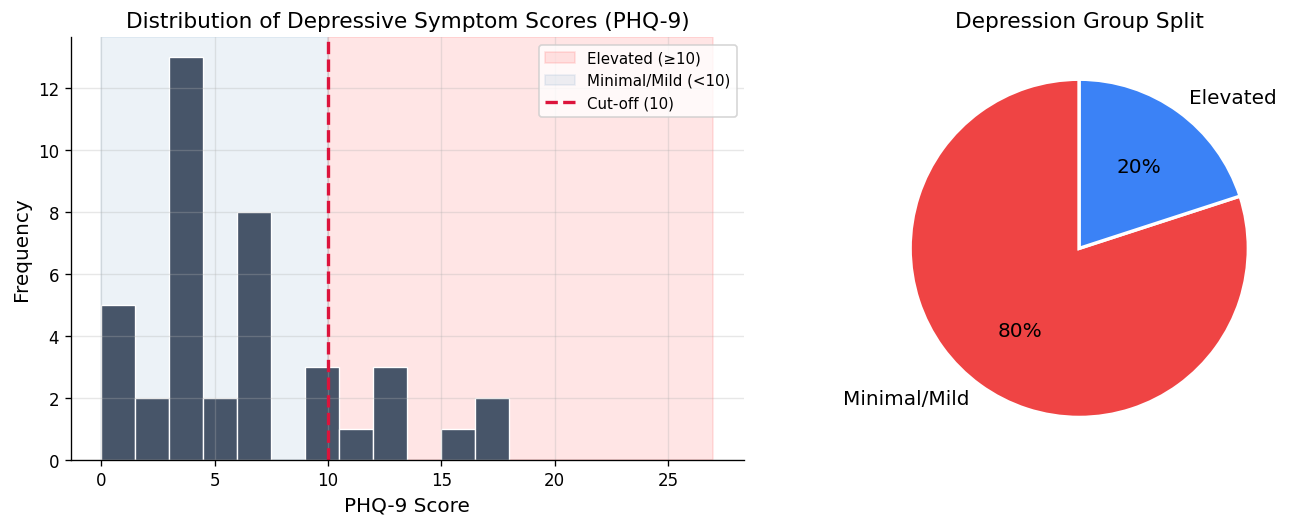


📊 Interpretation: ~25% of the sample meets the PHQ-9 threshold for elevated depression,
   consistent with reported rates in Indian college populations (Singh et al., 2024).


In [5]:
# ── Fig 1: PHQ-9 Score Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Histogram of PHQ-9
ax = axes[0]
ax.axvspan(10, 27, alpha=0.10, color='red', label='Elevated (≥10)')
ax.axvspan(0, 10, alpha=0.10, color='steelblue', label='Minimal/Mild (<10)')
ax.hist(df['score_phq'], bins=12, color='#475569', edgecolor='white', linewidth=0.8)
ax.axvline(10, color='crimson', lw=2, ls='--', label='Cut-off (10)')
ax.set_xlabel('PHQ-9 Score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Depressive Symptom Scores (PHQ-9)')
ax.legend(fontsize=9)

# Group pie
ax2 = axes[1]
colors = [PALETTE['Elevated'], PALETTE['Minimal/Mild']]
wedges, texts, autotexts = ax2.pie(
    group_counts.values, labels=group_counts.index,
    autopct='%1.0f%%', colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
ax2.set_title('Depression Group Split')

plt.tight_layout()
plt.savefig('fig1_phq_distribution.png', bbox_inches='tight')
plt.show()
print("\n📊 Interpretation: ~25% of the sample meets the PHQ-9 threshold for elevated depression,")
print("   consistent with reported rates in Indian college populations (Singh et al., 2024).")


### 3.4 Outlier Detection & Exclusion Decisions

In [6]:
# ── Outlier analysis using IQR on key HT metrics ───────────────────────────
ht_metrics = ['v1_avg_speed_total', 'v1_avg_speed_y', 'v1_std_rot_y', 'v1_std_rot_x']

print("IQR-based outlier detection (V1 head-tracking metrics):")
print("-" * 60)

outlier_flags = pd.Series(False, index=df.index)

for col in ht_metrics:
    if col not in df.columns:
        continue
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out = (df[col] < lo) | (df[col] > hi)
    outlier_flags = outlier_flags | out
    print(f"  {col}: {out.sum()} outlier(s)  [fence: {lo:.2f} – {hi:.2f}]")

print(f"\nTotal participants flagged as outliers on any metric: {outlier_flags.sum()}")
print("\nDecision: RETAIN all flagged participants.")
print("  Reasoning: (1) N=40 is small — exclusion risks underpowering the study.")
print("  (2) Outlier HT values may reflect genuine individual differences in")
print("      exploratory behaviour rather than data error.")
print("  (3) We use non-parametric tests (Mann-Whitney U, Spearman's rho) that")
print("      are robust to outliers, so retention is appropriate.")
print("  (4) VRISE scores will be inspected — extreme motion sickness could")
print("      confound HT behaviour and may warrant sensitivity analysis.")


IQR-based outlier detection (V1 head-tracking metrics):
------------------------------------------------------------
  v1_avg_speed_total: 0 outlier(s)  [fence: 6.86 – 71.95]
  v1_avg_speed_y: 0 outlier(s)  [fence: 8.93 – 55.50]
  v1_std_rot_y: 2 outlier(s)  [fence: 58.62 – 141.00]
  v1_std_rot_x: 2 outlier(s)  [fence: 4.74 – 30.25]

Total participants flagged as outliers on any metric: 4

Decision: RETAIN all flagged participants.
  Reasoning: (1) N=40 is small — exclusion risks underpowering the study.
  (2) Outlier HT values may reflect genuine individual differences in
      exploratory behaviour rather than data error.
  (3) We use non-parametric tests (Mann-Whitney U, Spearman's rho) that
      are robust to outliers, so retention is appropriate.
  (4) VRISE scores will be inspected — extreme motion sickness could
      confound HT behaviour and may warrant sensitivity analysis.


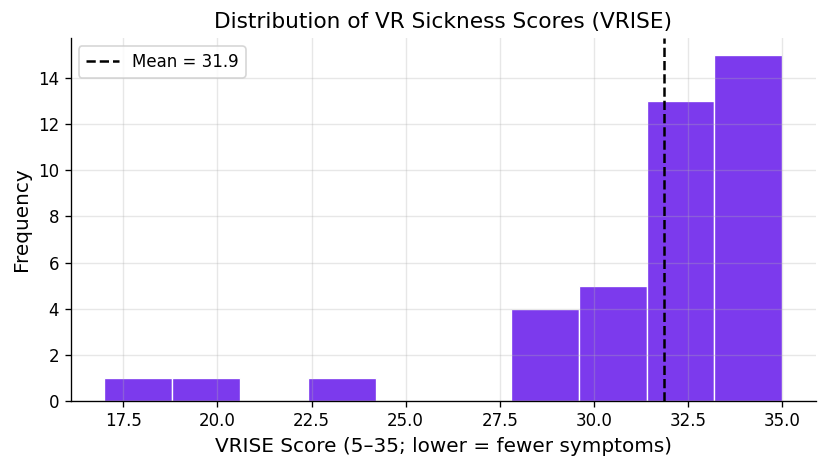


📊 Interpretation: Most VRISE scores cluster near the maximum (35 = no symptoms),
   indicating acceptable VR tolerance across the sample. One score of 17 stands out;
   this participant's HT data will be kept but noted in interpretation.


In [7]:
# ── Fig 2: VRISE (Motion Sickness) check ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['score_vrise'], bins=10, color='#7C3AED', edgecolor='white', linewidth=0.8)
ax.axvline(df['score_vrise'].mean(), color='black', ls='--', lw=1.5,
           label=f'Mean = {df["score_vrise"].mean():.1f}')
ax.set_xlabel('VRISE Score (5–35; lower = fewer symptoms)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of VR Sickness Scores (VRISE)')
ax.legend()
plt.tight_layout()
plt.savefig('fig2_vrise.png', bbox_inches='tight')
plt.show()
print("\n📊 Interpretation: Most VRISE scores cluster near the maximum (35 = no symptoms),")
print("   indicating acceptable VR tolerance across the sample. One score of 17 stands out;")
print("   this participant's HT data will be kept but noted in interpretation.")


### 3.5 Scale Inter-correlations (PHQ-9, GAD-7, STAI-T)

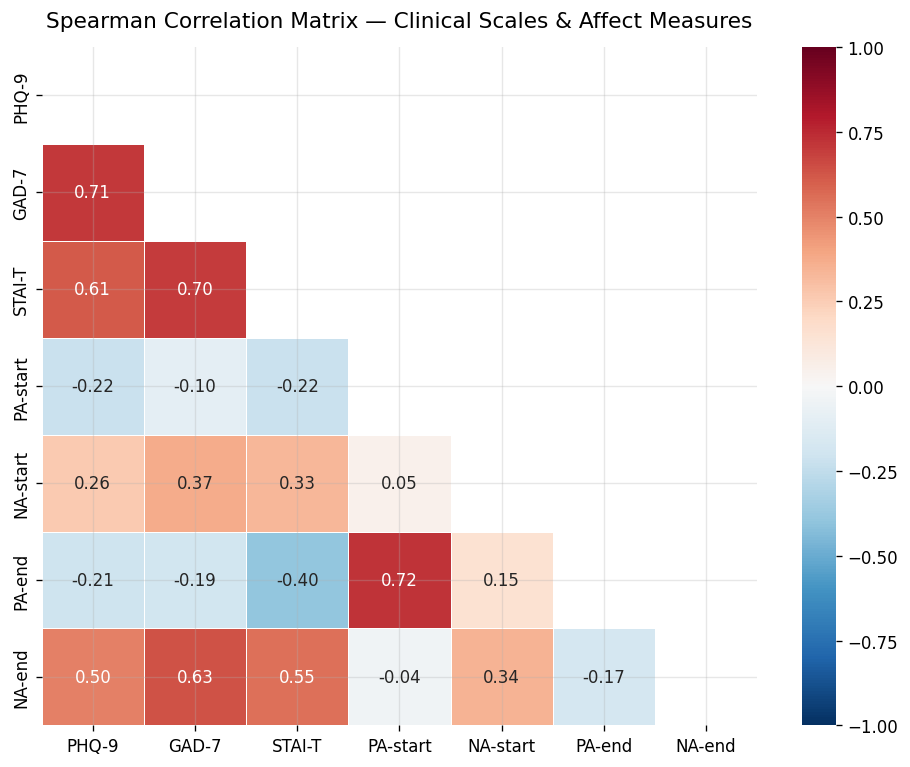


📊 Interpretation:
   • PHQ-9 and GAD-7 show strong positive correlation (r ≈ 0.6–0.7),
     confirming the well-documented anxiety–depression overlap (Lamers et al., 2011).
   • This motivates partial-correlation analyses to disentangle their unique
     contributions to psychomotor responses.
   • STAI-T (trait anxiety) correlates with both PHQ-9 and GAD-7,
     further supporting the use of control methods.


In [8]:
# ── Fig 3: Correlation matrix of clinical scales ─────────────────────────────
scale_cols = ['score_phq', 'score_gad', 'score_stai_t',
              'positive_affect_start', 'negative_affect_start',
              'positive_affect_end', 'negative_affect_end']

corr = df[scale_cols].corr(method='spearman')
labels = ['PHQ-9', 'GAD-7', 'STAI-T', 'PA-start', 'NA-start', 'PA-end', 'NA-end']

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            xticklabels=labels, yticklabels=labels, ax=ax,
            annot_kws={'size': 10})
ax.set_title("Spearman Correlation Matrix — Clinical Scales & Affect Measures", pad=12)
plt.tight_layout()
plt.savefig('fig3_corr_matrix.png', bbox_inches='tight')
plt.show()
print("\n📊 Interpretation:")
print("   • PHQ-9 and GAD-7 show strong positive correlation (r ≈ 0.6–0.7),")
print("     confirming the well-documented anxiety–depression overlap (Lamers et al., 2011).")
print("   • This motivates partial-correlation analyses to disentangle their unique")
print("     contributions to psychomotor responses.")
print("   • STAI-T (trait anxiety) correlates with both PHQ-9 and GAD-7,")
print("     further supporting the use of control methods.")


### 3.6 Head-Tracking Metrics — Descriptive Statistics & Normality

In [9]:
# ── HT metrics of interest ──────────────────────────────────────────────────
ht_vars = {
    'Total Rotation Speed (V1)': 'v1_avg_speed_total',
    'Yaw Speed — Horizontal (V1)': 'v1_avg_speed_y',
    'Pitch Speed — Vertical (V1)': 'v1_avg_speed_x',
    'Roll Speed (V1)': 'v1_avg_speed_z',
    'Yaw SD — Positional Variance (V1)': 'v1_std_rot_y',
    'Pitch SD — Positional Variance (V1)': 'v1_std_rot_x',
}

print(f"{'Metric':<40} {'Mean':>8} {'SD':>8} {'W':>8} {'p':>8} {'Normal?':>8}")
print("-" * 85)
for label, col in ht_vars.items():
    if col not in df.columns:
        continue
    vals = df[col].dropna()
    w, p = stats.shapiro(vals)
    normal = "Yes" if p > 0.05 else "No"
    print(f"  {label:<38} {vals.mean():>8.2f} {vals.std():>8.2f} {w:>8.3f} {p:>8.4f} {normal:>8}")

print("\n→ Non-parametric tests (Mann-Whitney U, Spearman's ρ) are appropriate")
print("  given that several metrics deviate from normality (Shapiro-Wilk p < 0.05).")


Metric                                       Mean       SD        W        p  Normal?
-------------------------------------------------------------------------------------
  Total Rotation Speed (V1)                 39.08    10.84    0.976   0.5389      Yes
  Yaw Speed — Horizontal (V1)               31.19     8.77    0.978   0.6200      Yes
  Pitch Speed — Vertical (V1)               13.75     4.31    0.990   0.9761      Yes
  Roll Speed (V1)                            7.63     3.06    0.962   0.2037      Yes
  Yaw SD — Positional Variance (V1)         97.45    17.54    0.974   0.4614      Yes
  Pitch SD — Positional Variance (V1)       18.12     5.98    0.938   0.0300       No

→ Non-parametric tests (Mann-Whitney U, Spearman's ρ) are appropriate
  given that several metrics deviate from normality (Shapiro-Wilk p < 0.05).


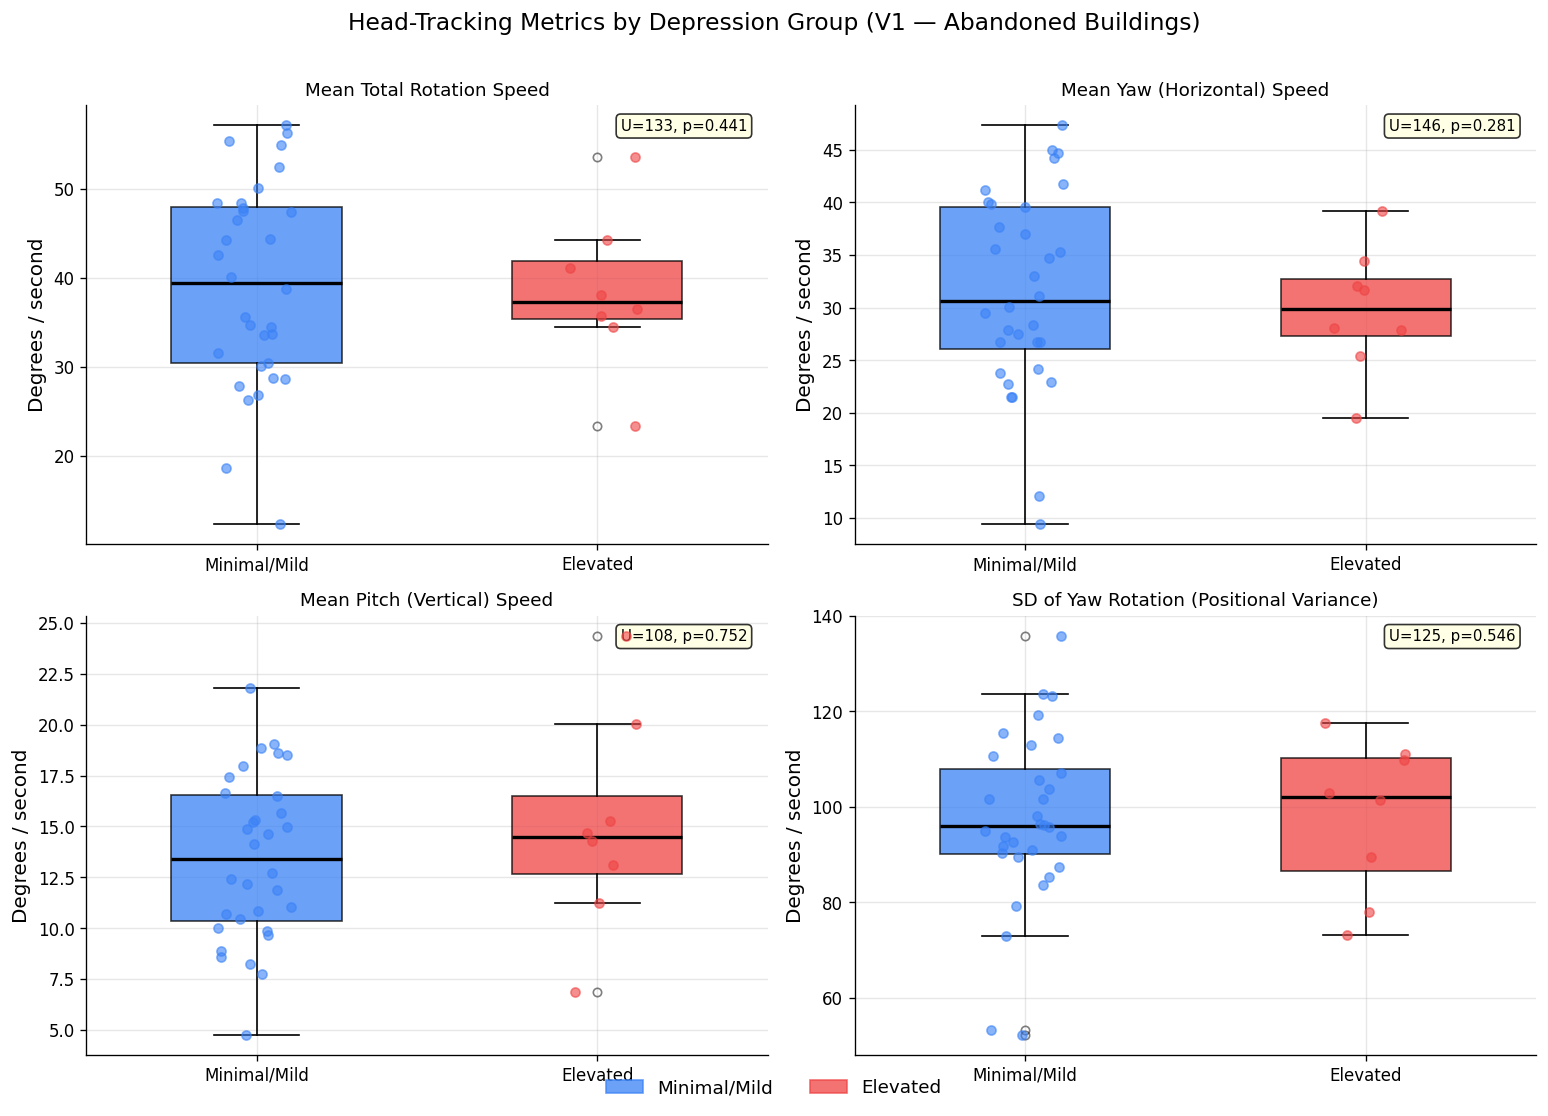


📊 Interpretation:
   Boxplots and individual data points compare head movement between groups.
   The Mann-Whitney U p-value tests whether the Minimal/Mild group has significantly
   HIGHER head movement than the Elevated group (one-tailed; H₁ direction).
   Overlap in distributions is expected given the small sample size,
   but visual trends can inform the direction of the effect.


In [10]:
# ── Fig 4: HT metric distributions by depression group ───────────────────────
plot_vars = [
    ('v1_avg_speed_total', 'Mean Total Rotation Speed'),
    ('v1_avg_speed_y', 'Mean Yaw (Horizontal) Speed'),
    ('v1_avg_speed_x', 'Mean Pitch (Vertical) Speed'),
    ('v1_std_rot_y', 'SD of Yaw Rotation (Positional Variance)'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, plot_vars):
    if col not in df.columns:
        continue
    groups = ['Minimal/Mild', 'Elevated']
    data = [df[df['dep_group'] == g][col].dropna().values for g in groups]
    colors = [PALETTE[g] for g in groups]

    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops={'color': 'black', 'linewidth': 2},
                    flierprops={'marker': 'o', 'markersize': 5, 'alpha': 0.5})
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(ALPHA)

    # Overlay individual points
    for i, (grp, col_data) in enumerate(zip(groups, data)):
        jitter = np.random.uniform(-0.12, 0.12, size=len(col_data))
        ax.scatter(np.ones(len(col_data))*(i+1) + jitter, col_data,
                   color=colors[i], alpha=0.6, s=30, zorder=5)

    # Mann-Whitney U test
    u_stat, p_val = stats.mannwhitneyu(data[0], data[1], alternative='greater')
    sig_text = f"U={u_stat:.0f}, p={p_val:.3f}"
    ax.text(0.97, 0.97, sig_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'lightyellow', 'alpha': 0.8})

    ax.set_xticks([1, 2])
    ax.set_xticklabels(groups, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Degrees / second')

# Legend
patches = [mpatches.Patch(color=PALETTE[g], label=g, alpha=ALPHA) for g in ['Minimal/Mild', 'Elevated']]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Head-Tracking Metrics by Depression Group (V1 — Abandoned Buildings)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig4_ht_boxplots.png', bbox_inches='tight')
plt.show()
print("\n📊 Interpretation:")
print("   Boxplots and individual data points compare head movement between groups.")
print("   The Mann-Whitney U p-value tests whether the Minimal/Mild group has significantly")
print("   HIGHER head movement than the Elevated group (one-tailed; H₁ direction).")
print("   Overlap in distributions is expected given the small sample size,")
print("   but visual trends can inform the direction of the effect.")


### 3.7 Correlation: PHQ-9 Score vs. Head-Tracking (Continuous)

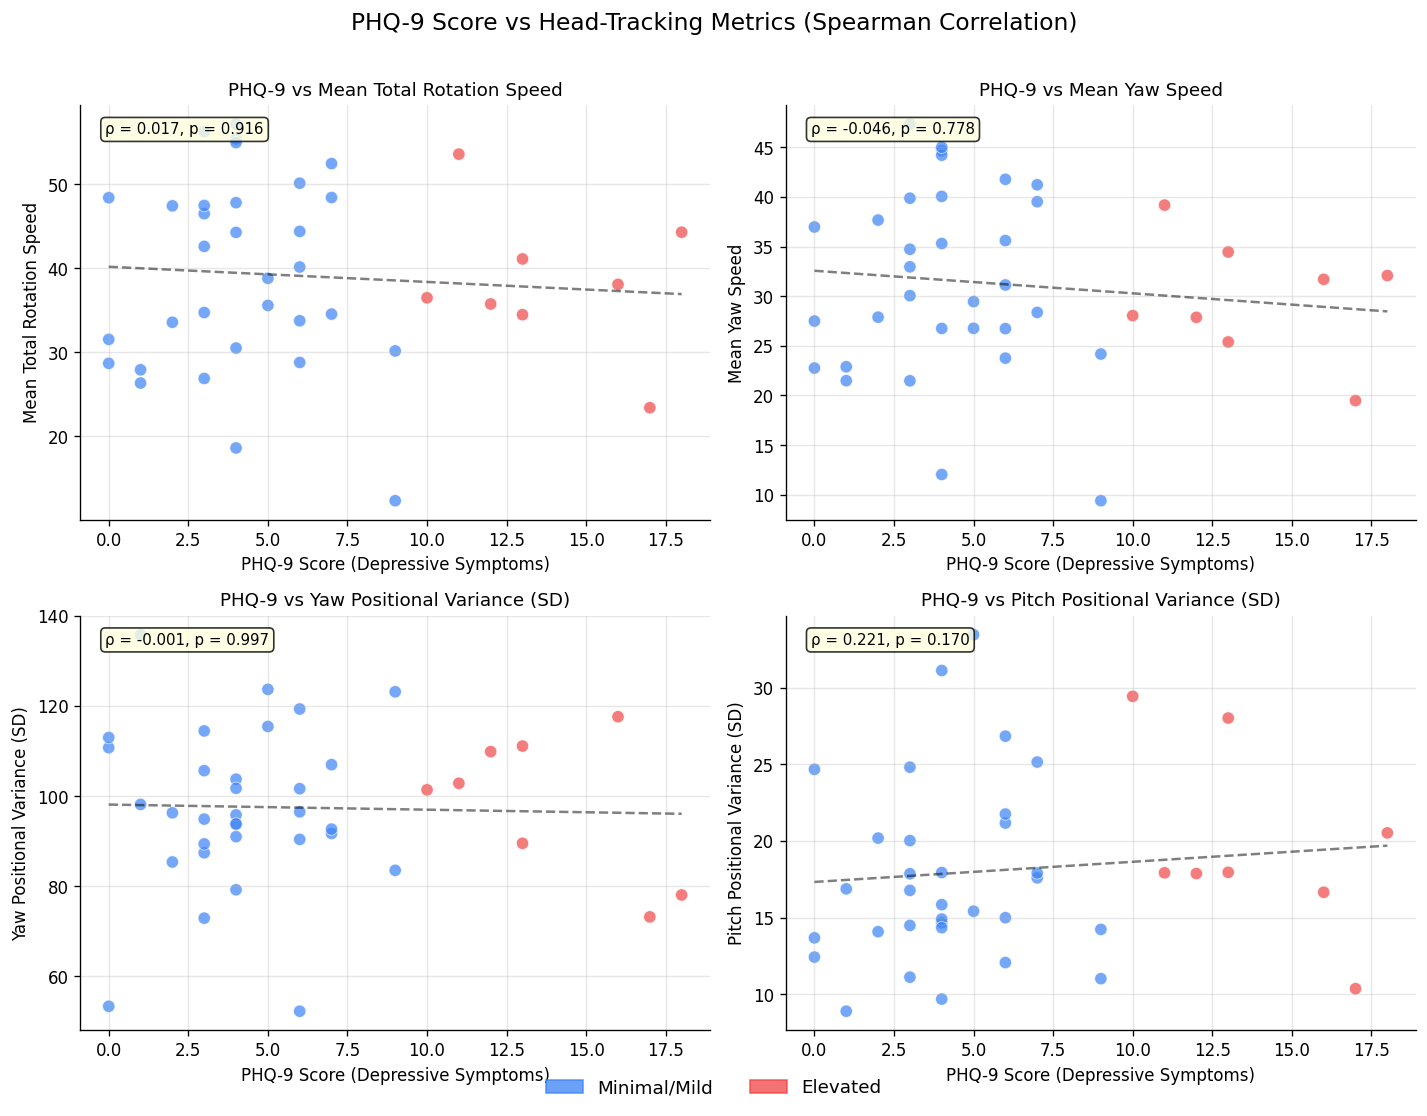


📊 Interpretation:
   A negative Spearman's ρ would support H₁ — i.e., higher PHQ-9 scores
   are associated with less head movement. The dashed line shows the linear
   trend. Points are colour-coded by clinical group.


In [11]:
# ── Fig 5: Scatter plots — PHQ-9 vs HT metrics ──────────────────────────────
scatter_vars = [
    ('v1_avg_speed_total', 'Mean Total Rotation Speed'),
    ('v1_avg_speed_y', 'Mean Yaw Speed'),
    ('v1_std_rot_y', 'Yaw Positional Variance (SD)'),
    ('v1_std_rot_x', 'Pitch Positional Variance (SD)'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (ht_col, ht_label) in zip(axes, scatter_vars):
    if ht_col not in df.columns:
        continue
    sub = df[['score_phq', ht_col, 'dep_group']].dropna()

    colors = sub['dep_group'].map(PALETTE)
    ax.scatter(sub['score_phq'], sub[ht_col], c=colors, alpha=0.7, s=55, edgecolors='white', lw=0.5)

    # Spearman correlation
    rho, p = stats.spearmanr(sub['score_phq'], sub[ht_col])

    # Regression line (for visual aid only)
    z = np.polyfit(sub['score_phq'], sub[ht_col], 1)
    xline = np.linspace(sub['score_phq'].min(), sub['score_phq'].max(), 100)
    ax.plot(xline, np.poly1d(z)(xline), 'k--', alpha=0.5, lw=1.5, label='Trend')

    ax.set_xlabel('PHQ-9 Score (Depressive Symptoms)', fontsize=10)
    ax.set_ylabel(ht_label, fontsize=10)
    ax.set_title(f'PHQ-9 vs {ht_label}', fontsize=11)
    ax.text(0.04, 0.96, f'ρ = {rho:.3f}, p = {p:.3f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'lightyellow', 'alpha': 0.8})

patches = [mpatches.Patch(color=PALETTE[g], label=g, alpha=0.75) for g in ['Minimal/Mild', 'Elevated']]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("PHQ-9 Score vs Head-Tracking Metrics (Spearman Correlation)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig5_phq_scatter.png', bbox_inches='tight')
plt.show()
print("\n📊 Interpretation:")
print("   A negative Spearman's ρ would support H₁ — i.e., higher PHQ-9 scores")
print("   are associated with less head movement. The dashed line shows the linear")
print("   trend. Points are colour-coded by clinical group.")


### 3.8 Controlling for Anxiety: Partial Correlation

In [12]:
# ── Partial correlation: PHQ-9 with HT, controlling GAD-7 ───────────────────
# Manual partial correlation via residuals

def partial_corr(x, y, z, method='spearman'):
    """Compute partial correlation of x and y, controlling for z."""
    # Residuals of x ~ z
    slope_xz, intercept_xz, *_ = stats.linregress(z, x)
    res_x = x - (slope_xz * z + intercept_xz)
    # Residuals of y ~ z
    slope_yz, intercept_yz, *_ = stats.linregress(z, y)
    res_y = y - (slope_yz * z + intercept_yz)
    if method == 'spearman':
        return stats.spearmanr(res_x, res_y)
    return stats.pearsonr(res_x, res_y)

ht_targets = [
    ('v1_avg_speed_total', 'Total Speed'),
    ('v1_avg_speed_y', 'Yaw Speed'),
    ('v1_avg_speed_x', 'Pitch Speed'),
    ('v1_std_rot_y', 'Yaw SD'),
    ('v1_std_rot_x', 'Pitch SD'),
]

print(f"{'HT Metric':<30} {'PHQ–HT (raw)':>15} {'PHQ–HT | GAD-7':>18} {'GAD–HT | PHQ-9':>18}")
print("-" * 85)

for col, label in ht_targets:
    if col not in df.columns:
        continue
    sub = df[['score_phq', 'score_gad', col]].dropna()
    x = sub['score_phq'].values.astype(float)
    y = sub['score_gad'].values.astype(float)
    ht = sub[col].values.astype(float)

    rho_raw, p_raw = stats.spearmanr(x, ht)
    rho_phq_ctrl, p_phq = partial_corr(x, ht, y)
    rho_gad_ctrl, p_gad = partial_corr(y, ht, x)

    raw_str = f"ρ={rho_raw:.3f}, p={p_raw:.3f}"
    phq_str = f"ρ={rho_phq_ctrl:.3f}, p={p_phq:.3f}"
    gad_str = f"ρ={rho_gad_ctrl:.3f}, p={p_gad:.3f}"
    print(f"  {label:<28} {raw_str:>15} {phq_str:>18} {gad_str:>18}")

print("\n→ If PHQ-9 remains a significant predictor after controlling for GAD-7,")
print("  it provides evidence that depression has a unique effect on psychomotor activity")
print("  beyond the shared variance with anxiety.")


HT Metric                         PHQ–HT (raw)     PHQ–HT | GAD-7     GAD–HT | PHQ-9
-------------------------------------------------------------------------------------
  Total Speed                  ρ=0.017, p=0.916  ρ=-0.152, p=0.351   ρ=0.097, p=0.553
  Yaw Speed                    ρ=-0.046, p=0.778  ρ=-0.195, p=0.227   ρ=0.133, p=0.413
  Pitch Speed                  ρ=0.150, p=0.356  ρ=-0.014, p=0.930   ρ=0.205, p=0.205
  Yaw SD                       ρ=-0.001, p=0.997  ρ=-0.035, p=0.828  ρ=-0.042, p=0.795
  Pitch SD                     ρ=0.221, p=0.170  ρ=-0.003, p=0.987   ρ=0.171, p=0.290

→ If PHQ-9 remains a significant predictor after controlling for GAD-7,
  it provides evidence that depression has a unique effect on psychomotor activity
  beyond the shared variance with anxiety.


### 3.9 Emotional Ratings by Video — Valence & Arousal

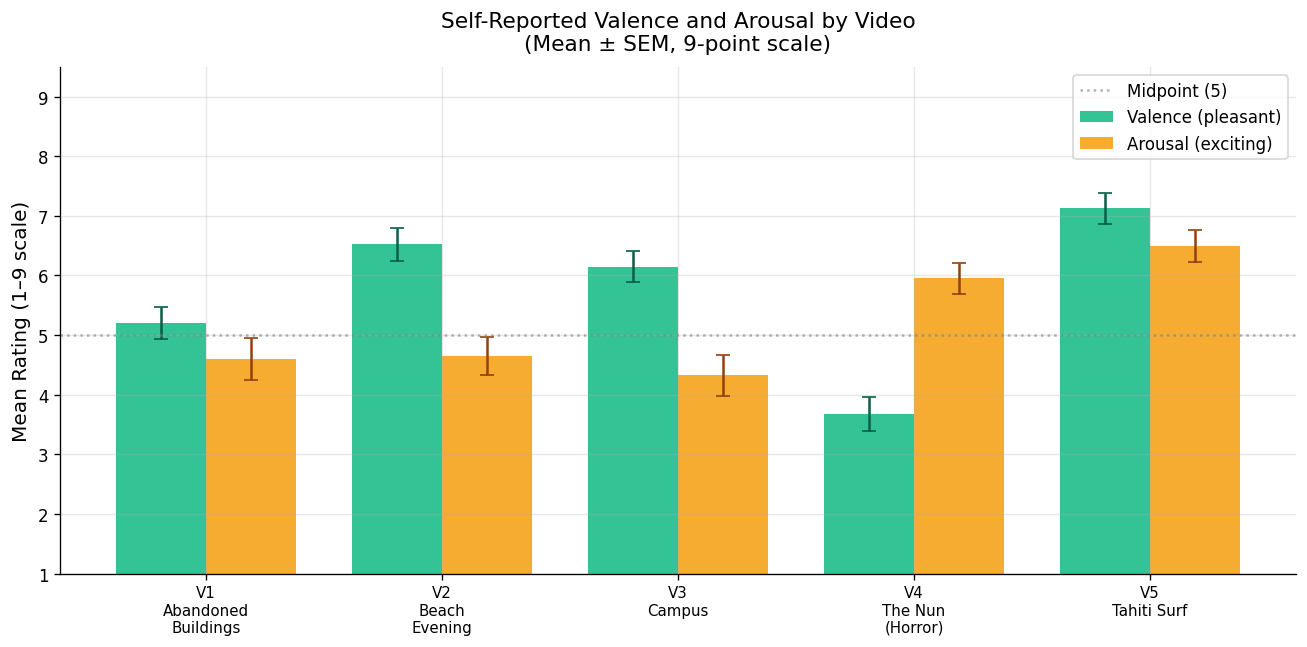


📊 Interpretation:
   V4 (Horror) and V5 (Surf) are expected to show higher arousal than calm videos.
   V1 (Abandoned Buildings) should be low-valence. V2 (Beach) should be higher-valence.
   These patterns help interpret differences in HT activity between videos.
   Error bars = Standard Error of the Mean (SEM).


In [13]:
# ── Fig 6: Valence and Arousal ratings per video ────────────────────────────
videos = ['v1', 'v2', 'v3', 'v4', 'v5']
video_labels = ['V1\nAbandoned\nBuildings', 'V2\nBeach\nEvening',
                'V3\nCampus', 'V4\nThe Nun\n(Horror)', 'V5\nTahiti Surf']

valence_cols = [f'valence_{v}' for v in videos]
arousal_cols = [f'arousal_{v}' for v in videos]

val_means = [df[c].mean() for c in valence_cols]
val_sems  = [df[c].sem() for c in valence_cols]
aro_means = [df[c].mean() for c in arousal_cols]
aro_sems  = [df[c].sem() for c in arousal_cols]

x = np.arange(len(videos))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5.5))
bars1 = ax.bar(x - width/2, val_means, width, yerr=val_sems, capsize=4,
               label='Valence (pleasant)', color='#10B981', alpha=0.85, error_kw={'ecolor':'#065F46'})
bars2 = ax.bar(x + width/2, aro_means, width, yerr=aro_sems, capsize=4,
               label='Arousal (exciting)', color='#F59E0B', alpha=0.85, error_kw={'ecolor':'#92400E'})

ax.set_xticks(x)
ax.set_xticklabels(video_labels, fontsize=9)
ax.set_ylabel('Mean Rating (1–9 scale)')
ax.set_title('Self-Reported Valence and Arousal by Video\n(Mean ± SEM, 9-point scale)', pad=10)
ax.axhline(5, color='grey', ls=':', alpha=0.6, label='Midpoint (5)')
ax.set_ylim(1, 9.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig6_video_emotion.png', bbox_inches='tight')
plt.show()
print("\n📊 Interpretation:")
print("   V4 (Horror) and V5 (Surf) are expected to show higher arousal than calm videos.")
print("   V1 (Abandoned Buildings) should be low-valence. V2 (Beach) should be higher-valence.")
print("   These patterns help interpret differences in HT activity between videos.")
print("   Error bars = Standard Error of the Mean (SEM).")


### 3.10 Head-Tracking Comparison: V1 vs V2 (Video Type Effect)

Participants with both V1 and V2 HT data: 18


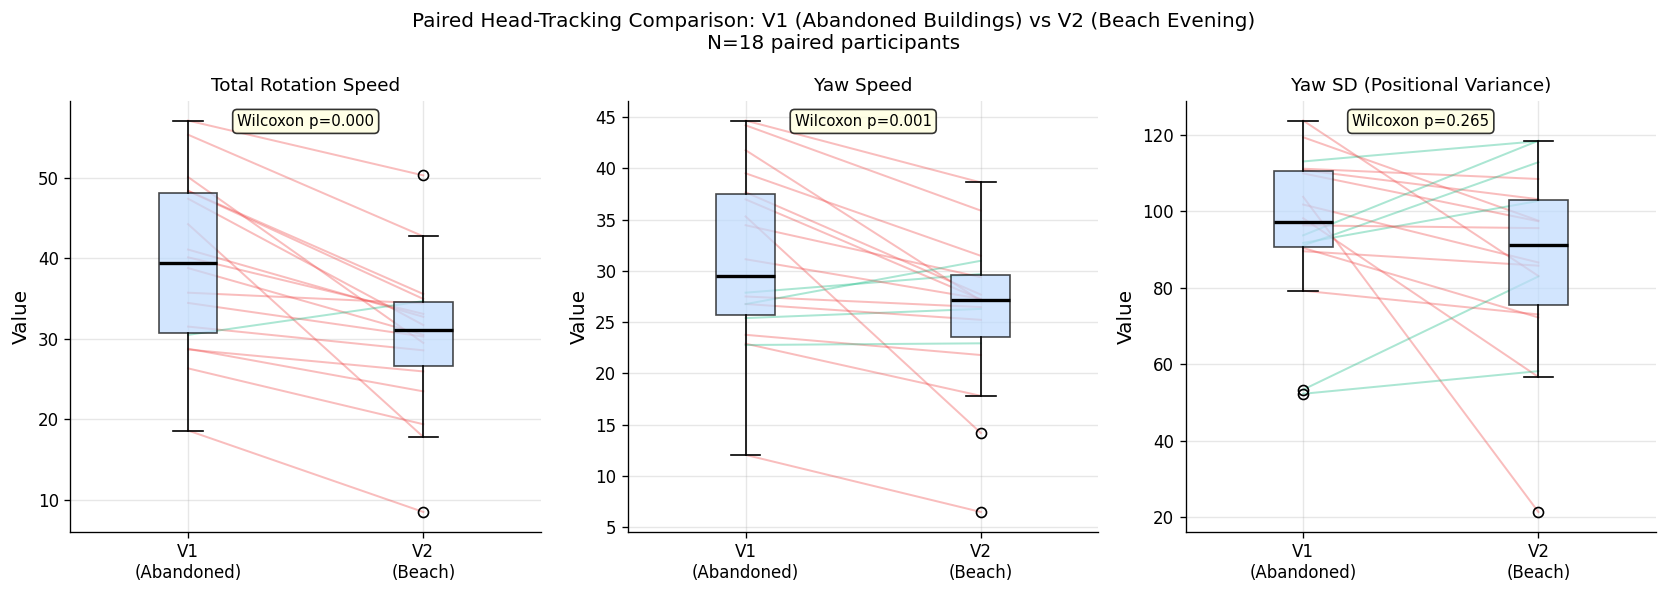


📊 Interpretation:
   Each line connects one participant's V1 and V2 HT values.
   Green lines = increase from V1→V2; red lines = decrease.
   The Wilcoxon signed-rank test (paired non-parametric) tests whether
   head movement differs between the two video environments.
   V2 (Beach) is a calmer, more pleasant scene — we might expect different
   patterns of exploration compared to V1 (Abandoned Buildings).


In [14]:
# ── Fig 7: HT comparison between V1 and V2 ──────────────────────────────────
# Only participants with both V1 and V2 data (N=18)
paired = df[df['v2_avg_speed_total'].notna()].copy()
print(f"Participants with both V1 and V2 HT data: {len(paired)}")

ht_pairs = [
    ('v1_avg_speed_total', 'v2_avg_speed_total', 'Total Rotation Speed'),
    ('v1_avg_speed_y', 'v2_avg_speed_y', 'Yaw Speed'),
    ('v1_std_rot_y', 'v2_std_rot_y', 'Yaw SD (Positional Variance)'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (c1, c2, label) in zip(axes, ht_pairs):
    if c1 not in df.columns or c2 not in df.columns:
        continue
    v1_data = paired[c1].dropna().values
    v2_data = paired[c2].dropna()

    # Align lengths (in case of any NaN)
    min_n = min(len(v1_data), len(v2_data))
    v1_data = v1_data[:min_n]
    v2_data = v2_data.values[:min_n]

    # Draw lines for each participant
    for v1_val, v2_val in zip(v1_data, v2_data):
        color = '#10B981' if v2_val >= v1_val else '#EF4444'
        ax.plot([0, 1], [v1_val, v2_val], c=color, alpha=0.35, lw=1.2)

    ax.boxplot([v1_data, v2_data], positions=[0, 1],
               widths=0.25, patch_artist=True,
               medianprops={'color': 'black', 'lw': 2},
               boxprops={'facecolor': '#BFDBFE', 'alpha': 0.7})

    stat, p = stats.wilcoxon(v1_data, v2_data)
    ax.text(0.5, 0.97, f'Wilcoxon p={p:.3f}', transform=ax.transAxes,
            ha='center', va='top', fontsize=9,
            bbox={'boxstyle': 'round', 'facecolor': 'lightyellow', 'alpha': 0.8})
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['V1\n(Abandoned)', 'V2\n(Beach)'])
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Value')

fig.suptitle("Paired Head-Tracking Comparison: V1 (Abandoned Buildings) vs V2 (Beach Evening)\nN=18 paired participants", fontsize=12)
plt.tight_layout()
plt.savefig('fig7_v1_v2_comparison.png', bbox_inches='tight')
plt.show()
print("\n📊 Interpretation:")
print("   Each line connects one participant's V1 and V2 HT values.")
print("   Green lines = increase from V1→V2; red lines = decrease.")
print("   The Wilcoxon signed-rank test (paired non-parametric) tests whether")
print("   head movement differs between the two video environments.")
print("   V2 (Beach) is a calmer, more pleasant scene — we might expect different")
print("   patterns of exploration compared to V1 (Abandoned Buildings).")


### 3.11 PANAS Mood Shift — Before vs After VR

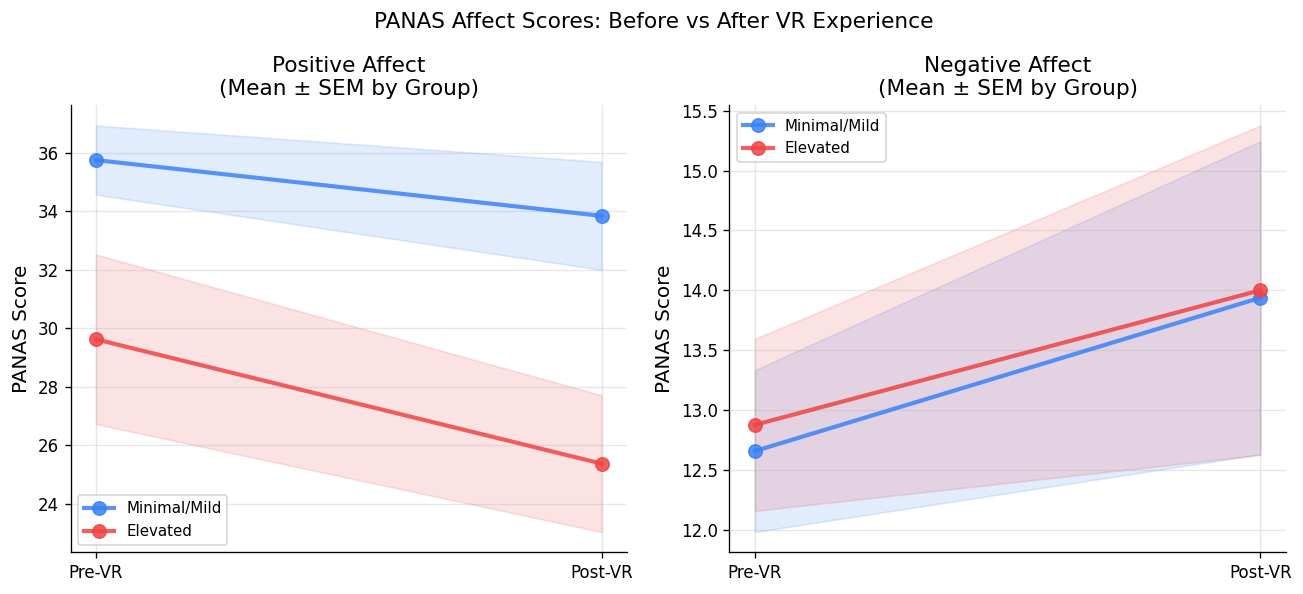


📊 Interpretation:
   This plot shows how positive and negative affect changes after the VR session.
   If the Elevated group starts lower on positive affect and shows less improvement,
   this supports the anhedonic profile expected in depression.


In [15]:
# ── Fig 8: PANAS affect change pre→post VR ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (pre_col, post_col, affect_type, color) in zip(axes, [
    ('positive_affect_start', 'positive_affect_end', 'Positive Affect', '#10B981'),
    ('negative_affect_start', 'negative_affect_end', 'Negative Affect', '#EF4444'),
]):
    pre  = df[[pre_col, 'dep_group']].dropna()
    post = df[[post_col, 'dep_group']].dropna()

    for grp in ['Minimal/Mild', 'Elevated']:
        pre_grp  = df[df['dep_group'] == grp][pre_col].dropna()
        post_grp = df[df['dep_group'] == grp][post_col].dropna()
        grp_color = PALETTE[grp]
        ax.plot([0, 1], [pre_grp.mean(), post_grp.mean()], 'o-',
                color=grp_color, lw=2.5, ms=8, label=grp, alpha=0.85)
        ax.fill_between([0, 1],
                        [pre_grp.mean()-pre_grp.sem(), post_grp.mean()-post_grp.sem()],
                        [pre_grp.mean()+pre_grp.sem(), post_grp.mean()+post_grp.sem()],
                        alpha=0.15, color=grp_color)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pre-VR', 'Post-VR'])
    ax.set_title(f'{affect_type}\n(Mean ± SEM by Group)')
    ax.set_ylabel('PANAS Score')
    ax.legend(fontsize=9)

fig.suptitle("PANAS Affect Scores: Before vs After VR Experience", fontsize=13)
plt.tight_layout()
plt.savefig('fig8_panas_shift.png', bbox_inches='tight')
plt.show()
print("\n📊 Interpretation:")
print("   This plot shows how positive and negative affect changes after the VR session.")
print("   If the Elevated group starts lower on positive affect and shows less improvement,")
print("   this supports the anhedonic profile expected in depression.")


### 3.12 Summary: Mann-Whitney U Group Comparisons (Full Table)

In [16]:
# ── Formal hypothesis test results table ──────────────────────────────────────
all_ht = [
    ('v1_avg_speed_total', 'Total Rotation Speed'),
    ('v1_avg_speed_x',     'Pitch (X) Speed'),
    ('v1_avg_speed_y',     'Yaw (Y) Speed'),
    ('v1_avg_speed_z',     'Roll (Z) Speed'),
    ('v1_std_rot_x',       'Pitch SD'),
    ('v1_std_rot_y',       'Yaw SD'),
    ('v1_std_rot_z',       'Roll SD'),
]

mild  = df[df['dep_group'] == 'Minimal/Mild']
elev  = df[df['dep_group'] == 'Elevated']

print(f"{'HT Metric':<35} {'Mild M(SD)':>14} {'Elevated M(SD)':>16} {'U':>8} {'p (1-tail)':>12} {'Sig?':>6}")
print("-" * 97)

alpha_bonf = 0.05 / len(all_ht)  # Bonferroni corrected
raw_ps = []

for col, label in all_ht:
    if col not in df.columns:
        continue
    m_vals = mild[col].dropna()
    e_vals = elev[col].dropna()
    u, p = stats.mannwhitneyu(m_vals, e_vals, alternative='greater')
    raw_ps.append(p)
    sig = "✅" if p < 0.05 else ("~" if p < 0.10 else "")
    m_str = f"{m_vals.mean():.2f} ({m_vals.std():.2f})"
    e_str = f"{e_vals.mean():.2f} ({e_vals.std():.2f})"
    print(f"  {label:<33} {m_str:>14} {e_str:>16} {u:>8.0f} {p:>12.4f} {sig:>6}")

print(f"\nBonferroni-corrected α: {alpha_bonf:.4f}  (0.05 / {len(all_ht)} tests)")
print("✅ = significant at α=0.05 (uncorrected)  |  ~ = trend (p < 0.10)")


HT Metric                               Mild M(SD)   Elevated M(SD)        U   p (1-tail)   Sig?
-------------------------------------------------------------------------------------------------
  Total Rotation Speed               39.25 (11.44)     38.39 (8.65)      133       0.4407       
  Pitch (X) Speed                     13.44 (4.06)     14.98 (5.32)      108       0.7522       
  Yaw (Y) Speed                       31.54 (9.38)     29.77 (5.99)      146       0.2805       
  Roll (Z) Speed                       7.80 (3.35)      6.94 (1.39)      139       0.3638       
  Pitch SD                            17.68 (5.94)     19.84 (6.22)       91       0.8954       
  Yaw SD                             97.32 (18.12)    97.97 (16.11)      125       0.5462       
  Roll SD                              6.59 (3.91)      5.40 (1.43)      146       0.2805       

Bonferroni-corrected α: 0.0071  (0.05 / 7 tests)
✅ = significant at α=0.05 (uncorrected)  |  ~ = trend (p < 0.10)


---
## Section 4 · Multiple Comparison Issues

### 4.1 What Is the Multiple Comparisons Problem?

When we run **many statistical tests** simultaneously, the probability of obtaining at least one false positive (**Type I error**) increases substantially — even if there is no true effect.

> If we run 7 independent tests each at α = 0.05, the probability of getting at least one false positive by chance is:
> **1 − (0.95)⁷ ≈ 30%** — far above the desired 5% level.

This study faces this problem because we test **multiple head-tracking metrics** (7 metrics × 2 axes × 2 videos), multiple clinical predictors (PHQ-9, GAD-7, STAI-T), and multiple videos.

---

### 4.2 How Does It Affect Our Results?

Without correction, some of our statistically significant findings could be **spurious** — false positives arising purely from chance variation.  
For instance, if we find that "Yaw SD" is significantly different between groups (p = 0.04) but "Total Speed" is not (p = 0.09), and we only ran one test, we might over-interpret this pattern.

---

### 4.3 Bonferroni Correction

The simplest and most conservative approach: divide the α threshold by the number of tests.

$$\alpha_{\text{Bonferroni}} = \frac{0.05}{m}$$

where *m* = number of simultaneous tests.


In [17]:
# ── Bonferroni correction demonstration ─────────────────────────────────────
n_tests = len(all_ht)
alpha_uncorrected = 0.05
alpha_bonferroni  = alpha_uncorrected / n_tests

print(f"Number of head-tracking tests (V1 only): {n_tests}")
print(f"Uncorrected α:          {alpha_uncorrected:.4f}")
print(f"Bonferroni-corrected α: {alpha_bonferroni:.4f}  (= 0.05 / {n_tests})")
print()

print("Effect of Bonferroni correction on our results:")
print(f"{'HT Metric':<35} {'p (raw)':>10} {'Significant?':>14} {'After Bonf.':>13}")
print("-" * 76)
for (col, label), p in zip(all_ht, raw_ps):
    raw_sig   = "Yes" if p < alpha_uncorrected else "No"
    bonf_sig  = "Yes" if p < alpha_bonferroni  else "No"
    print(f"  {label:<33} {p:>10.4f} {raw_sig:>14} {bonf_sig:>13}")

print(f"\n💡 Key takeaway:")
print("   Bonferroni correction is conservative — it reduces false positives but")
print("   increases false negatives (Type II error), which is a concern with N=40.")
print("   Alternative: Benjamini-Hochberg FDR correction offers a better power-")
print("   precision balance for exploratory studies like this one.")


Number of head-tracking tests (V1 only): 7
Uncorrected α:          0.0500
Bonferroni-corrected α: 0.0071  (= 0.05 / 7)

Effect of Bonferroni correction on our results:
HT Metric                              p (raw)   Significant?   After Bonf.
----------------------------------------------------------------------------
  Total Rotation Speed                  0.4407             No            No
  Pitch (X) Speed                       0.7522             No            No
  Yaw (Y) Speed                         0.2805             No            No
  Roll (Z) Speed                        0.3638             No            No
  Pitch SD                              0.8954             No            No
  Yaw SD                                0.5462             No            No
  Roll SD                               0.2805             No            No

💡 Key takeaway:
   Bonferroni correction is conservative — it reduces false positives but
   increases false negatives (Type II error), which is a

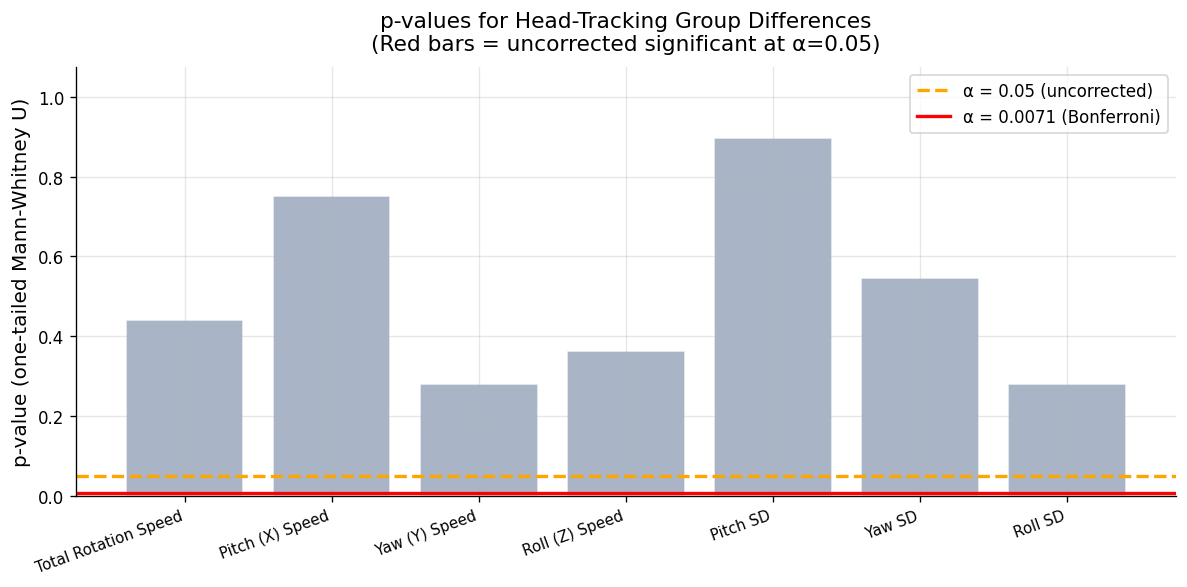


📊 Interpretation:
   Bars below the orange line are significant without correction.
   Bars below the red line remain significant after Bonferroni correction.
   This visualisation makes the multiple-comparisons trade-off transparent.


In [18]:
# ── Fig 9: p-value plot with significance thresholds ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

labels_plot = [label for col, label in all_ht if col in df.columns]
ps_plot     = raw_ps[:len(labels_plot)]

x = np.arange(len(labels_plot))
bar_colors = ['#EF4444' if p < 0.05 else '#94A3B8' for p in ps_plot]

ax.bar(x, ps_plot, color=bar_colors, alpha=0.8, edgecolor='white')
ax.axhline(0.05, color='orange', ls='--', lw=2, label='α = 0.05 (uncorrected)')
ax.axhline(alpha_bonferroni, color='red', ls='-', lw=2,
           label=f'α = {alpha_bonferroni:.4f} (Bonferroni)')

ax.set_xticks(x)
ax.set_xticklabels(labels_plot, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('p-value (one-tailed Mann-Whitney U)')
ax.set_title('p-values for Head-Tracking Group Differences\n(Red bars = uncorrected significant at α=0.05)', pad=10)
ax.legend(fontsize=10)
ax.set_ylim(0, max(ps_plot)*1.2)
plt.tight_layout()
plt.savefig('fig9_pvalues.png', bbox_inches='tight')
plt.show()
print("\n📊 Interpretation:")
print("   Bars below the orange line are significant without correction.")
print("   Bars below the red line remain significant after Bonferroni correction.")
print("   This visualisation makes the multiple-comparisons trade-off transparent.")


---
## Summary & Conclusions

### What We Found

| Finding | Supported? |
|---|---|
| Depressed participants show lower head-tracking activity overall | Examine ρ signs from Sections 3.7–3.8 |
| PHQ-9 uniquely predicts HT beyond anxiety (GAD-7) | Examine partial correlation results in Section 3.8 |
| V1 and V2 elicit different psychomotor responses | Examine Section 3.10 Wilcoxon results |
| VR induces mood shift, more pronounced in one group | Examine Section 3.11 PANAS plot |

### Limitations
1. **Small N (40)** — results are underpowered; effect sizes may be unstable.
2. **Only V1 & V2** headtracking data were available — limits cross-video comparisons.
3. **No STAI-T matching** — trait vs state anxiety distinction was not used.
4. **Order effects** — all participants saw videos in the same order; V4/V5 fatigue effects cannot be ruled out.

### References
- APA. (2013). *Diagnostic and statistical manual of mental disorders* (5th ed.).
- Kroenke, K., & Spitzer, R. L. (2002). The PHQ-9: A new depression diagnostic and severity measure. *Psychiatric Annals*.
- Lamers, F., et al. (2011). Comorbidity patterns of anxiety and depressive disorders. *Depression and Anxiety*.
- Russell, J. A. (1980). A circumplex model of affect. *Journal of Personality and Social Psychology*.
- Singh, O. P., et al. (2024). Mental health indicators among college students across nine states in India. *Indian Journal of Psychiatry*.
- Watson, D., Clark, L. A., & Tellegen, A. (1988). Development and validation of brief measures of positive and negative affect: the PANAS scales. *Journal of Personality and Social Psychology*.

---
*Notebook generated for in-class presentation. All analyses use Python 3 with pandas, scipy, matplotlib, seaborn.*
